In [1]:
import json
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from itertools import combinations


# Attention Analysis

## Caveats on interpreting attention as feature importance

Attention weights should **not** be directly interpreted as feature importance. High attention on a modality may indicate that the modality is predictively useful, but it may equally reflect that the modality is *heterogeneous* or has complex internal structure that demands more internal processing — not that it contributes useful signal.

Specifically, attention alone cannot:
- Prove that information has been transferred into AlphaEarth embeddings.
- Prove that spatial bias has been removed.

To strengthen the analysis we therefore combine attention with:
1. **Modality ablation** — performance when each modality is zeroed at inference.
2. **Attention vs. performance-drop scatter** — if a modality draws high attention *and* removing it causes a large RMSE increase, that supports the *importance* interpretation; if it draws high attention but removal causes little degradation, the attention is more likely driven by heterogeneity or noise.
3. **Per-stratum attention** — attention broken down by POI-density stratum, to check whether AE is more relied upon in POI-sparse areas.
4. **Representation similarity (CKA)** — a note on what CKA would add and how to run it.


In [2]:
# Models with saved attention arrays
MODELS = {
    "BASE": {
        "ckpt": "ckpt_livability",
        "modalities": ["RS", "DSM", "NLRS", "POI"],
        "drop_suffixes": {"RS": "_NULL_RS", "DSM": "_NULL_DSM",
                          "NLRS": "_NULL_GIU", "POI": "_noPOI"},
    },
    "AE": {
        "ckpt": "ckpt_livability_alphaearth",
        "modalities": ["RS", "DSM", "NLRS", "AE", "POI"],
        "drop_suffixes": {"RS": "_NULL_RS", "DSM": "_NULL_DSM",
                          "NLRS": "_NULL_GIU", "AE": "_alphazero", "POI": "_noPOI"},
    },
    "AS": {
        "ckpt": "ckpt_livability_anysat",
        "modalities": ["RS", "DSM", "NLRS", "AS", "POI"],
        "drop_suffixes": {"RS": "_NULL_RS", "DSM": "_NULL_DSM",
                          "NLRS": "_NULL_GIU", "POI": "_noPOI"},
    },
    "TM": {
        "ckpt": "ckpt_livability_terramind",
        "modalities": ["RS", "DSM", "NLRS", "TM", "POI"],
        "drop_suffixes": {"RS": "_NULL_RS", "DSM": "_NULL_DSM",
                          "NLRS": "_NULL_GIU", "POI": "_noPOI"},
    },
}

METRICS = ['rmse_lbm', 'rmse_tgts_fys', 'rmse_tgts_onv',
           'rmse_tgts_soc', 'rmse_tgts_vrz', 'rmse_tgts_won']
METRIC_LABELS = ['LIV', 'PHY', 'NUI', 'SOC', 'AME', 'HOU']

def load_rmse(ckpt, suffix=''):
    pattern = f"{ckpt}/Livability_test_0320{suffix}_eval_results_test_final.txt"
    files = glob.glob(pattern)
    if not files:
        return None
    with open(files[0]) as f:
        r = json.load(f)
    return np.array([r.get(m, np.nan) for m in METRICS])


## 1. Mean attention per modality

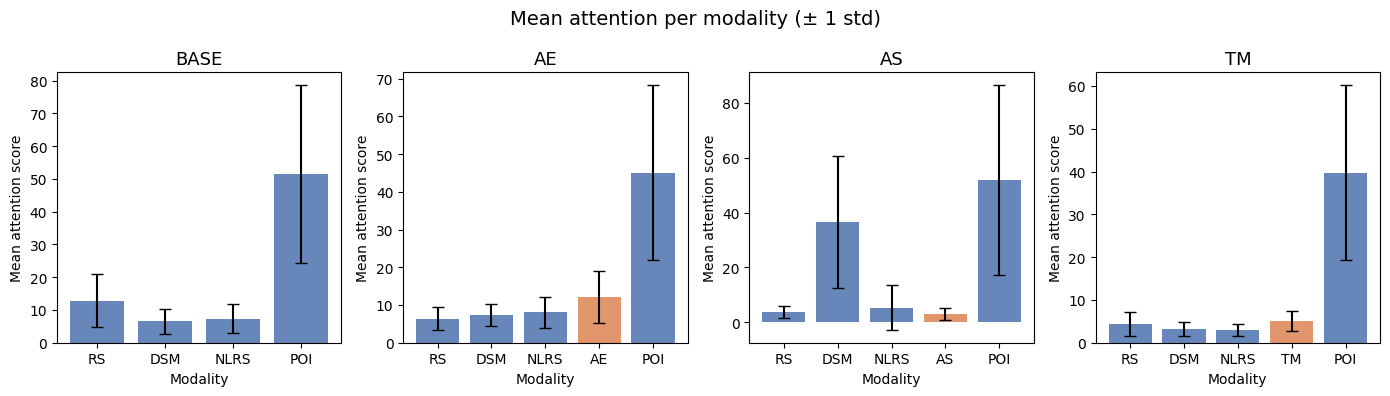

In [3]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 4), sharey=False)

for ax, (model_name, cfg) in zip(axes, MODELS.items()):
    attn = np.load(f"{cfg['ckpt']}/Livability_test_0320_attentions_test_final.npy")
    means = attn.mean(axis=0)
    stds  = attn.std(axis=0)
    mods  = cfg['modalities']
    colors = ['#4C72B0' if m not in ('AE','AS','TM') else '#DD8452' for m in mods]
    bars = ax.bar(mods, means, yerr=stds, color=colors, capsize=4, alpha=0.85)
    ax.set_title(model_name, fontsize=13)
    ax.set_ylabel('Mean attention score')
    ax.set_xlabel('Modality')

fig.suptitle('Mean attention per modality (± 1 std)', fontsize=14)
plt.tight_layout()
plt.savefig('figs/attention_mean_per_modality.pdf', bbox_inches='tight')
plt.show()


/tmp/ipykernel_2200021/1165812545.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([attn[:, i] for i in range(len(mods))],
/tmp/ipykernel_2200021/1165812545.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([attn[:, i] for i in range(len(mods))],
/tmp/ipykernel_2200021/1165812545.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([attn[:, i] for i in range(len(mods))],
/tmp/ipykernel_2200021/1165812545.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.

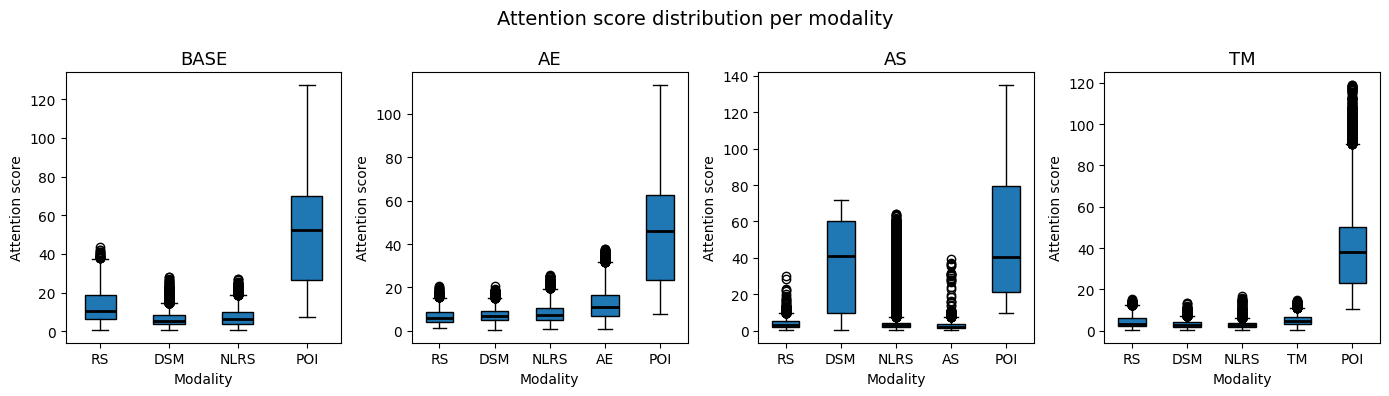

In [4]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(14, 4), sharey=False)

for ax, (model_name, cfg) in zip(axes, MODELS.items()):
    attn = np.load(f"{cfg['ckpt']}/Livability_test_0320_attentions_test_final.npy")
    mods = cfg['modalities']
    ax.boxplot([attn[:, i] for i in range(len(mods))],
               labels=mods, patch_artist=True,
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(model_name, fontsize=13)
    ax.set_ylabel('Attention score')
    ax.set_xlabel('Modality')

fig.suptitle('Attention score distribution per modality', fontsize=14)
plt.tight_layout()
plt.savefig('figs/attention_distribution.pdf', bbox_inches='tight')
plt.show()


## 2. Attention vs. performance drop after modality removal

For each modality we compute:
- **Mean attention** across the test set.
- **RMSE drop** = RMSE (modality zeroed at inference) − RMSE (full model).

A positive RMSE drop means the model performs worse without that modality — i.e. the modality was carrying useful information. We then examine whether high attention tracks high RMSE drop (*importance*) or whether the two diverge (*heterogeneity*).

In [5]:
records = []
for model_name, cfg in MODELS.items():
    ckpt = cfg['ckpt']
    attn = np.load(f"{ckpt}/Livability_test_0320_attentions_test_final.npy")
    rmse_full = load_rmse(ckpt)
    if rmse_full is None:
        continue
    for mi, mod in enumerate(cfg['modalities']):
        suffix = cfg['drop_suffixes'].get(mod)
        if suffix is None:
            continue
        rmse_drop_arr = load_rmse(ckpt, suffix)
        if rmse_drop_arr is None:
            continue
        mean_attn = float(attn[:, mi].mean())
        for ci, metric in enumerate(METRIC_LABELS):
            records.append({
                'model': model_name, 'modality': mod, 'metric': metric,
                'mean_attn': mean_attn,
                'rmse_drop': float(rmse_drop_arr[ci] - rmse_full[ci]),
            })

df_cmp = pd.DataFrame(records)
df_cmp.head(12)


,model,modality,metric,mean_attn,rmse_drop
0,BASE,RS,LIV,12.840050,0.050745
1,BASE,RS,PHY,12.840050,0.011208
2,BASE,RS,NUI,12.840050,0.017171
3,BASE,RS,SOC,12.840050,0.017723
4,BASE,RS,AME,12.840050,0.015959
5,BASE,RS,HOU,12.840050,0.016256
6,BASE,DSM,LIV,6.538408,0.001633
7,BASE,DSM,PHY,6.538408,0.005077
8,BASE,DSM,NUI,6.538408,0.000608
9,BASE,DSM,SOC,6.538408,0.000371


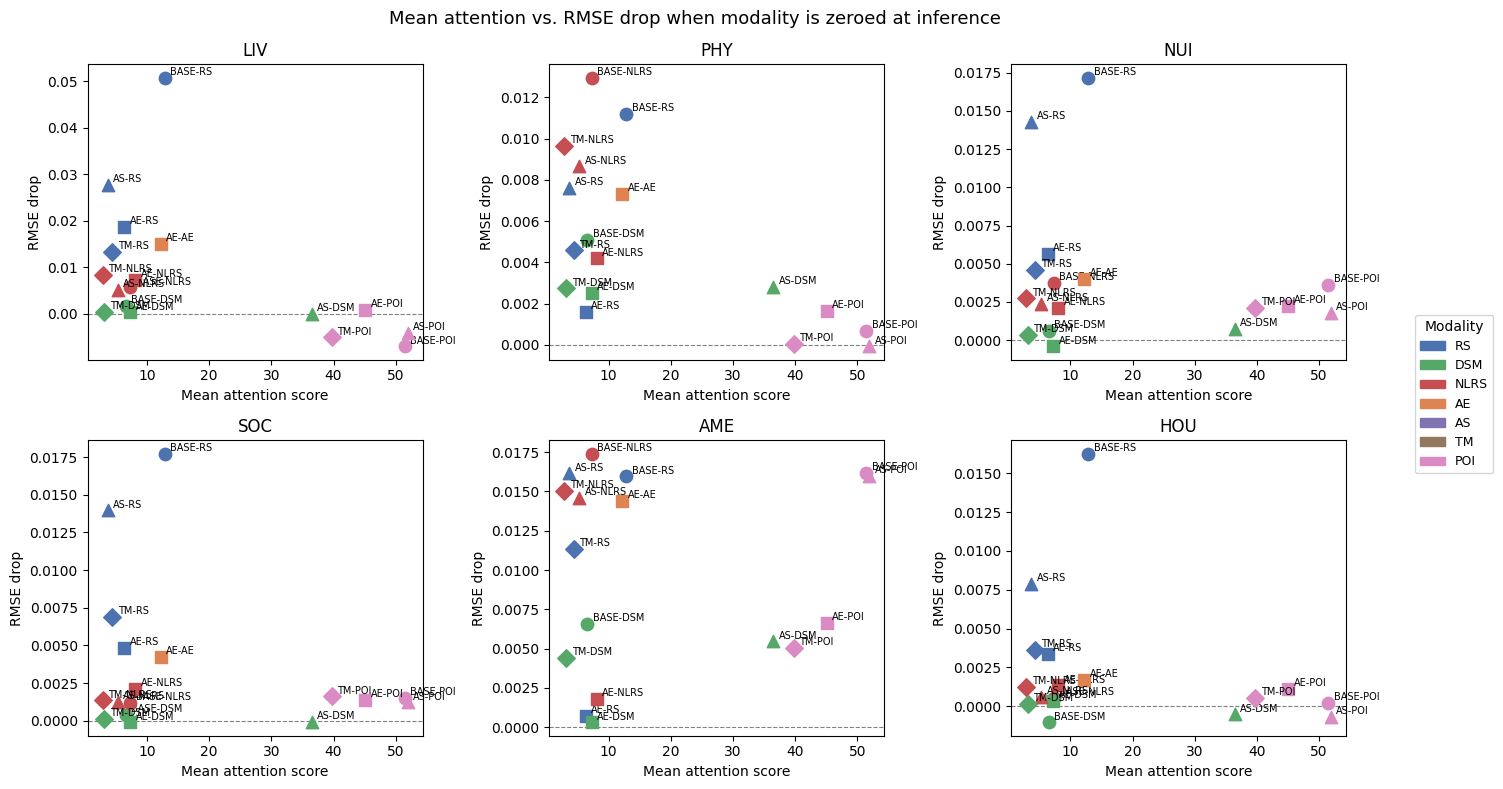

In [6]:
# Scatter: mean attention vs RMSE drop, one panel per metric, one point per (model, modality)
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

marker_map = {'BASE': 'o', 'AE': 's', 'AS': '^', 'TM': 'D'}
color_map  = {'RS': '#4C72B0', 'DSM': '#55A868', 'NLRS': '#C44E52',
              'AE': '#DD8452', 'AS': '#8172B2', 'TM': '#937860', 'POI': '#DA8BC3'}

for ax, metric in zip(axes, METRIC_LABELS):
    sub = df_cmp[df_cmp['metric'] == metric]
    for _, row in sub.iterrows():
        ax.scatter(row['mean_attn'], row['rmse_drop'],
                   marker=marker_map[row['model']],
                   color=color_map.get(row['modality'], 'grey'),
                   s=80, zorder=3)
        ax.annotate(f"{row['model']}-{row['modality']}",
                    (row['mean_attn'], row['rmse_drop']),
                    fontsize=7, textcoords='offset points', xytext=(4, 2))
    ax.axhline(0, color='grey', lw=0.8, linestyle='--')
    ax.set_xlabel('Mean attention score')
    ax.set_ylabel('RMSE drop')
    ax.set_title(metric)

# shared legend
mod_patches = [mpatches.Patch(color=c, label=m) for m, c in color_map.items()]
fig.legend(handles=mod_patches, title='Modality', bbox_to_anchor=(1.01, 0.5),
           loc='center left', fontsize=9)
fig.suptitle('Mean attention vs. RMSE drop when modality is zeroed at inference',
             fontsize=13)
plt.tight_layout()
plt.savefig('figs/attention_vs_rmse_drop.pdf', bbox_inches='tight')
plt.show()


In [7]:
# Summary table: LIV metric only, with quadrant labels
sub = df_cmp[df_cmp['metric'] == 'LIV'].copy()
attn_med = sub['mean_attn'].median()
drop_med = sub['rmse_drop'].median()

def quadrant(row):
    hi_attn = row['mean_attn'] > attn_med
    hi_drop = row['rmse_drop']  > drop_med
    if hi_attn and hi_drop:  return 'important'
    if hi_attn and not hi_drop: return 'heterogeneous'
    if not hi_attn and hi_drop: return 'underattended'
    return 'low'

sub['interpretation'] = sub.apply(quadrant, axis=1)
sub[['model', 'modality', 'mean_attn', 'rmse_drop', 'interpretation']]\
    .sort_values(['model', 'mean_attn'], ascending=[True, False])\
    .set_index(['model', 'modality'])


mean_attn  rmse_drop interpretation
model modality                                     
AE    POI       45.051167   0.000859  heterogeneous
      AE        12.182236   0.014962      important
      NLRS       8.061682   0.007289      important
      DSM        7.245459   0.000247            low
      RS         6.323402   0.018618  underattended
AS    POI       51.902485  -0.004076  heterogeneous
      DSM       36.460274  -0.000114  heterogeneous
      NLRS       5.279425   0.005045            low
      RS         3.675768   0.027663  underattended
BASE  POI       51.433723  -0.007041  heterogeneous
      RS        12.840050   0.050745      important
      NLRS       7.287934   0.005618  underattended
      DSM        6.538408   0.001633            low
TM    POI       39.741657  -0.005124  heterogeneous
      RS         4.362103   0.013277  underattended
      DSM        3.129755   0.000351            low
      NLRS       2.876846   0.008381  underattended

## 3. Per-stratum attention: does AE substitute for POI in sparse areas?

We split the test set by POI-density stratum and compute mean attention per modality in each stratum. If AlphaEarth is especially useful in POI-sparse areas, we would expect its attention score to be relatively higher in the *none* and *sparse* strata.

           RS     DSM    NLRS         AE        POI
none    9.870  10.202  10.839  22.485001  12.767000
sparse  8.035   8.766  10.174  15.575000  31.405001
low     6.808   7.512   8.806  12.692000  42.271999
medium  5.254   6.327   7.164   9.741000  53.563000
dense   3.989   5.425   5.419   6.529000  64.866997


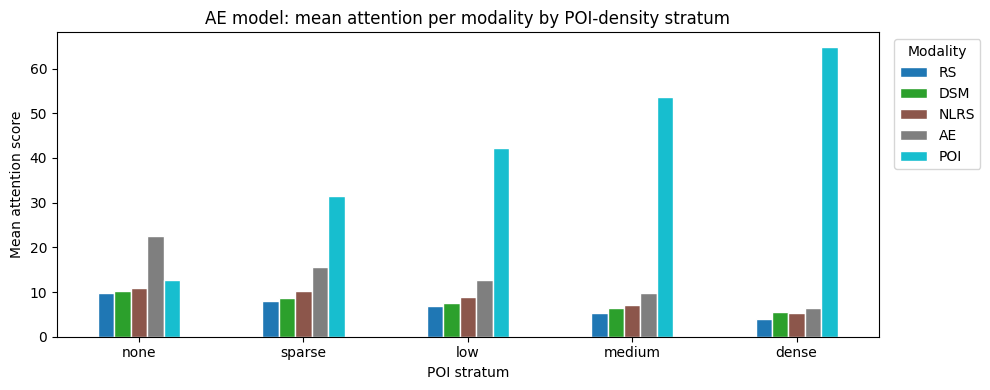

In [8]:
import re

def _count_poi(text):
    text = (text or '').strip()
    if not text or text.lower() == 'null': return 0
    return len([e for e in re.split(r'  +', text) if e.strip()])

_poi_counts = []
with open('data_livability/json/Livability_test_0320.json') as _f:
    for _line in _f:
        _line = _line.strip()
        if _line:
            _poi_counts.append(_count_poi(json.loads(_line).get('text', '')))
_poi_counts = np.array(_poi_counts)

STRATA = {
    'none':   np.where(_poi_counts == 0)[0],
    'sparse': np.where(_poi_counts == 1)[0],
    'low':    np.where((_poi_counts >= 2) & (_poi_counts <= 3))[0],
    'medium': np.where((_poi_counts >= 4) & (_poi_counts <= 8))[0],
    'dense':  np.where(_poi_counts > 8)[0],
}

# Focus on AE model; same analysis can be applied to others
cfg = MODELS['AE']
attn = np.load(f"{cfg['ckpt']}/Livability_test_0320_attentions_test_final.npy")
mods = cfg['modalities']

strata_means = {}
for stratum, idx in STRATA.items():
    strata_means[stratum] = attn[idx].mean(axis=0)

df_strata = pd.DataFrame(strata_means, index=mods).T
print(df_strata.round(3))

ax = df_strata.plot(kind='bar', figsize=(10, 4), rot=0,
                    colormap='tab10', edgecolor='white')
ax.set_xlabel('POI stratum')
ax.set_ylabel('Mean attention score')
ax.set_title('AE model: mean attention per modality by POI-density stratum')
ax.legend(title='Modality', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('figs/attention_by_poi_stratum.pdf', bbox_inches='tight')
plt.show()


         attn_AE  attn_RS  drop_AE_LIV  drop_RS_LIV
stratum                                            
none     22.4849   9.8698       0.0224       0.0385
sparse   15.5745   8.0353       0.0230       0.0197
low      12.6918   6.8085       0.0140       0.0165
medium    9.7409   5.2536       0.0125       0.0181
dense     6.5292   3.9887       0.0106       0.0101


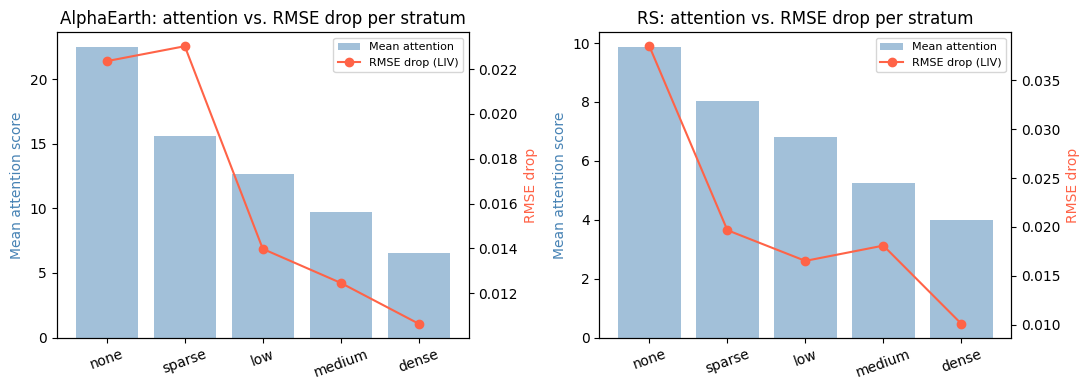

In [9]:
# Compare AE attention with AE RMSE drop per stratum
from tex_utils import save_tex

def _city_rmse(pp, tp, idx):
    p, t = np.load(pp)[idx], np.load(tp)[idx]
    return np.sqrt(np.mean((p - t) ** 2, axis=0))

cfg = MODELS['AE']
ckpt = cfg['ckpt']
preds_full = f"{ckpt}/Livability_test_0320_preds_test_final.npy"
tgts_full  = f"{ckpt}/Livability_test_0320_tgts_test_final.npy"
preds_noAE = glob.glob(f"{ckpt}/Livability_test_0320_alphazero_preds_test_final.npy")
preds_noRS = glob.glob(f"{ckpt}/Livability_test_0320_NULL_RS_preds_test_final.npy")

rows = []
for stratum, idx in STRATA.items():
    rmse_full = _city_rmse(preds_full, tgts_full, idx)
    mean_attn_AE = float(attn[idx, mods.index('AE')].mean())
    mean_attn_RS = float(attn[idx, mods.index('RS')].mean())
    row = {'stratum': stratum, 'attn_AE': mean_attn_AE, 'attn_RS': mean_attn_RS}
    if preds_noAE:
        rmse_noAE = _city_rmse(preds_noAE[0], tgts_full, idx)
        row['drop_AE_LIV'] = float(rmse_noAE[0] - rmse_full[0])
    if preds_noRS:
        rmse_noRS = _city_rmse(preds_noRS[0], tgts_full, idx)
        row['drop_RS_LIV'] = float(rmse_noRS[0] - rmse_full[0])
    rows.append(row)

df_strat_drop = pd.DataFrame(rows).set_index('stratum')
print(df_strat_drop.round(4))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (attn_col, drop_col, title) in zip(axes, [
    ('attn_AE', 'drop_AE_LIV', 'AlphaEarth'),
    ('attn_RS', 'drop_RS_LIV', 'RS'),
]):
    ax2 = ax.twinx()
    x = range(len(df_strat_drop))
    ax.bar(x, df_strat_drop[attn_col], alpha=0.5, label='Mean attention', color='steelblue')
    ax2.plot(x, df_strat_drop[drop_col], 'o-', color='tomato', label='RMSE drop (LIV)')
    ax.set_xticks(list(x)); ax.set_xticklabels(df_strat_drop.index, rotation=20)
    ax.set_ylabel('Mean attention score', color='steelblue')
    ax2.set_ylabel('RMSE drop', color='tomato')
    ax.set_title(f'{title}: attention vs. RMSE drop per stratum')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)
plt.tight_layout()
plt.savefig('figs/attention_vs_drop_by_stratum.pdf', bbox_inches='tight')
plt.show()


## 4. Attention–RMSE-drop correlation

In [10]:
# Pearson and Spearman correlation between attention and RMSE drop across modalities
# (LIV metric; per model)
print(f"{'Model':<8} {'Pearson r':>10} {'p':>8} {'Spearman r':>12} {'p':>8}")
print('-' * 50)
for model_name in MODELS:
    sub = df_cmp[(df_cmp['model'] == model_name) & (df_cmp['metric'] == 'LIV')]
    if len(sub) < 3:
        continue
    r_p, p_p = pearsonr(sub['mean_attn'], sub['rmse_drop'])
    r_s, p_s = spearmanr(sub['mean_attn'], sub['rmse_drop'])
    print(f"{model_name:<8} {r_p:>10.3f} {p_p:>8.3f} {r_s:>12.3f} {p_s:>8.3f}")


Model     Pearson r        p   Spearman r        p
--------------------------------------------------
BASE         -0.392    0.608       -0.200    0.800
AE           -0.482    0.411       -0.300    0.624
AS           -0.772    0.228       -1.000    0.000
TM           -0.744    0.256       -0.400    0.600


## 5. Representation similarity (CKA) — method note

**Centred Kernel Alignment (CKA)** measures the similarity between two sets of intermediate representations. To test whether AlphaEarth embeddings overlap with RS or POI features we would compare:

- The AE embedding vectors (the `AE` token passed into the fusion layer) against
- The RS image feature vectors from the baseline encoder.

High CKA between AE and RS features would suggest the embedding is largely recoding information already present in the RS stream. Low CKA despite high AE attention would confirm that AE carries novel, complementary information.

**What is needed:**
- Extract intermediate encoder features by re-running inference with forward hooks   (hook into the image projection layer output for each modality token).
- Save tensors of shape `(N, D)` for each modality per model.
- Compute linear CKA: `CKA(K, L) = ||L^T K||_F^2 / (||K^T K||_F ||L^T L||_F)`.

A reference implementation (numpy-only, O(N²) memory) is shown below and can be wired to saved feature files once they are extracted.


In [11]:
def linear_cka(X, Y):
    """Linear CKA between two centred feature matrices X, Y of shape (N, D)."""
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    XtX = X.T @ X
    YtY = Y.T @ Y
    YtX = Y.T @ X
    return np.linalg.norm(YtX, 'fro') ** 2 / (
        np.linalg.norm(XtX, 'fro') * np.linalg.norm(YtY, 'fro')
    )

# Example usage once features are extracted:
# ae_features = np.load('ckpt_livability_alphaearth/ae_token_features.npy')  # (N, D)
# rs_features = np.load('ckpt_livability_alphaearth/rs_token_features.npy')  # (N, D)
# cka_score = linear_cka(ae_features, rs_features)
# print(f'CKA(AE, RS) = {cka_score:.4f}')

print('CKA implementation ready. Run inference with forward hooks to extract features.')


CKA implementation ready. Run inference with forward hooks to extract features.
